# Лабораторная работа 1. Регрессия и метод главных компонент

## 1. Введение

Цель лабораторной работы — изучение основ линейной регрессии, построение простейших моделей регрессии на реальных данных и оценка качества полученных моделей.

В работе рассматривается задача прогнозирования количества аренд велосипедов за час на основе погодных условий, времени суток, дня недели и других характеристик.

## 2. Описание датасета

В работе используется датасет **Bike Sharing Dataset**, содержащий почасовые данные об аренде велосипедов.

Для исследования выбран полный месяц — май 2011 года. После фильтрации используется 744 наблюдения.

### Основные переменные

- `hr` — час суток, от 0 до 23;
- `holiday` — признак праздничного дня;
- `weekday` — день недели;
- `weathersit` — категория погодных условий;
- `temp` — нормализованная температура;
- `hum` — нормализованная влажность;
- `windspeed` — нормализованная скорость ветра;
- `cnt` — общее количество аренд велосипедов за час, целевая переменная.

Признаки `casual` и `registered` не используются в качестве факторов модели, поскольку непосредственно входят в целевую переменную `cnt`: `cnt = casual + registered`. Их использование привело бы к утечке информации о целевой переменной.

Также не используются идентификатор `instant`, дата `dteday`, год `yr`, сезон `season`, месяц `mnth` и `workingday`. Признак `atemp` будет рассмотрен при анализе мультиколлинеарности.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan


В работе используются библиотеки `pandas` и `numpy` для обработки данных, `matplotlib` для построения графиков, `scikit-learn` для обучения моделей и PCA, а также `statsmodels` для расчёта VIF и проведения теста Бреуша — Пагана.

In [2]:
df = pd.read_csv('hour.csv')
df['dteday'] = pd.to_datetime(df['dteday'])

print('Первые 5 строк:')
print(df.head())

print('\nРазмер исходного датасета:')
print(df.shape)

print('\nИнформация о датасете:')
print(df.info())

print('\nНазвания столбцов:')
print(df.columns.tolist())

print('\nКоличество пропущенных значений:')
print(df.isnull().sum())

print('\nОсновная статистика:')
print(df.describe())

Первые 5 строк:
   instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0     2787 2011-05-01       2   0     5   0        0        0           0   
1     2788 2011-05-01       2   0     5   1        0        0           0   
2     2789 2011-05-01       2   0     5   2        0        0           0   
3     2790 2011-05-01       2   0     5   3        0        0           0   
4     2791 2011-05-01       2   0     5   4        0        0           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.42  0.4242  0.67     0.0896      19          77   96  
1           1  0.42  0.4242  0.69     0.1045       9          50   59  
2           1  0.42  0.4242  0.77     0.1045       7          43   50  
3           1  0.40  0.4091  0.82     0.1045       8          15   23  
4           1  0.40  0.4091  0.76     0.1045       6          11   17  

Размер исходного датасета:
(744, 17)

Информация о датасете:
<class 'pandas.core.frame.D

На первом этапе выполнен первичный анализ исходного датасета. Проверены размер таблицы, названия и типы переменных, наличие пропущенных значений и основные статистические характеристики.

После проверки данных выполняется ограничение периода исследования до мая 2011 года.

In [3]:
df = df[
    (df['dteday'].dt.year == 2011) &
    (df['dteday'].dt.month == 5)
].copy()

print('Размер датасета за май 2011 года:')
print(df.shape)

print('\nПериод:')
print(df['dteday'].min(), '—', df['dteday'].max())

print('\nКоличество пропущенных значений:')
print(df.isnull().sum())

print('\nОсновная статистика:')
print(df.describe())

Размер датасета за май 2011 года:
(744, 17)

Период:
2011-05-01 00:00:00 — 2011-05-31 00:00:00

Количество пропущенных значений:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Основная статистика:
           instant               dteday  season     yr   mnth          hr  \
count   744.000000                  744   744.0  744.0  744.0  744.000000   
mean   3158.500000  2011-05-16 00:00:00     2.0    0.0    5.0   11.500000   
min    2787.000000  2011-05-01 00:00:00     2.0    0.0    5.0    0.000000   
25%    2972.750000  2011-05-08 00:00:00     2.0    0.0    5.0    5.750000   
50%    3158.500000  2011-05-16 00:00:00     2.0    0.0    5.0   11.500000   
75%    3344.250000  2011-05-24 00:00:00     2.0    0.0    5.0   17.250000   
max    3530.000000  2011-

После ограничения периода получено **744 наблюдения** за май 2011 года — с 1 по 31 мая.

В выбранном наборе данных пропущенные значения отсутствуют. Поэтому заполнение или удаление строк с пропусками для данной выборки не требуется.

Выбор полного месяца позволяет работать с однородным временным периодом и одновременно уменьшает объём данных до размера, удобного для учебного исследования.

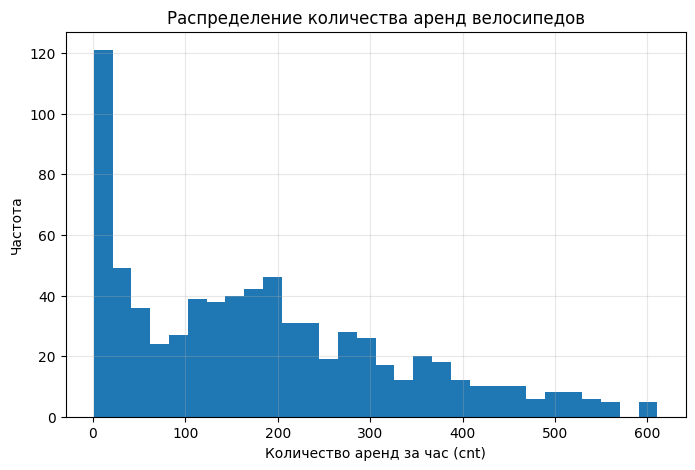

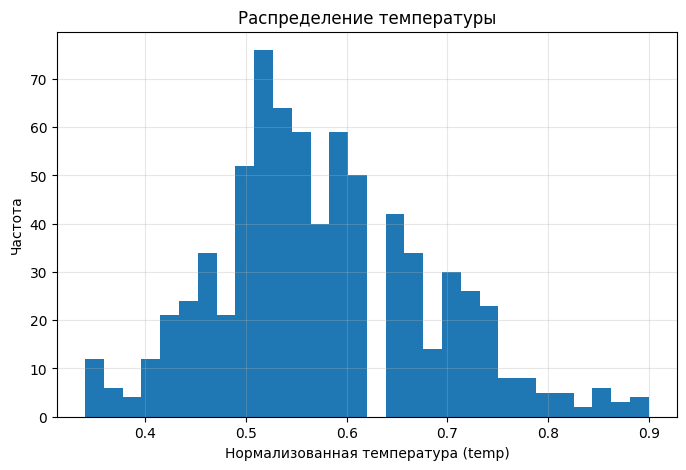

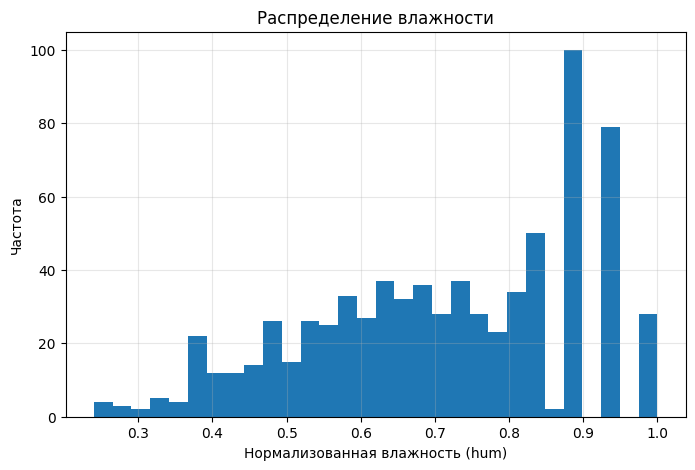

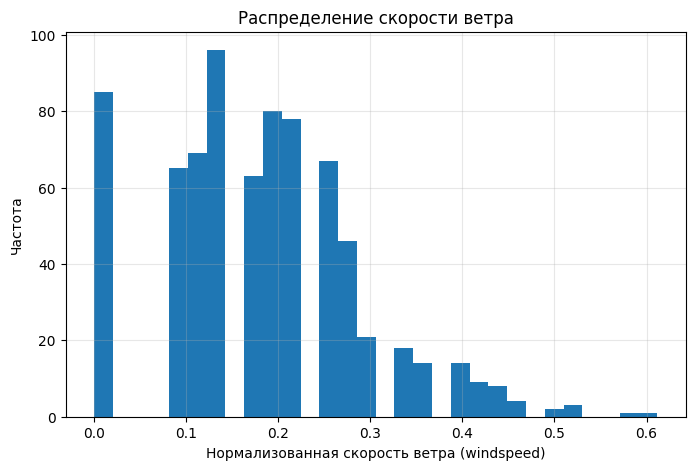

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=30)
plt.title('Распределение количества аренд велосипедов')
plt.xlabel('Количество аренд за час (cnt)')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['temp'], bins=30)
plt.title('Распределение температуры')
plt.xlabel('Нормализованная температура (temp)')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['hum'], bins=30)
plt.title('Распределение влажности')
plt.xlabel('Нормализованная влажность (hum)')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['windspeed'], bins=30)
plt.title('Распределение скорости ветра')
plt.xlabel('Нормализованная скорость ветра (windspeed)')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.show()

На графиках представлены распределения целевой переменной `cnt` и основных количественных признаков `temp`, `hum` и `windspeed`.

Распределение `cnt` является неоднородным: количество аренд заметно изменяется в зависимости от времени суток и условий окружающей среды. Распределения температуры, влажности и скорости ветра показывают диапазоны значений, которые будут использоваться при построении моделей.

Таким образом, уже на этапе визуального анализа можно предположить, что целевая переменная зависит не от одного фактора, а от совокупности нескольких признаков.

## 3. Подготовка данных

Перед построением моделей необходимо удалить признаки, которые не используются в дальнейшем анализе, а также подготовить категориальные переменные.

На данном этапе сохраняется `atemp`, поскольку сначала необходимо проверить мультиколлинеарность. После расчёта VIF этот признак будет удалён из итогового набора признаков.

In [5]:
df_prepared = df.drop(columns=[
    'instant',
    'dteday',
    'yr',
    'season',
    'mnth',
    'casual',
    'registered',
    'workingday'
]).copy()

print('Данные после удаления ненужных признаков:')
print(df_prepared.head())

print('\nРазмер подготовленного набора:')
print(df_prepared.shape)

print('\nОставшиеся переменные:')
print(df_prepared.columns.tolist())

print('\nПропущенные значения:')
print(df_prepared.isnull().sum())

Данные после удаления ненужных признаков:
   hr  holiday  weekday  weathersit  temp   atemp   hum  windspeed  cnt
0   0        0        0           1  0.42  0.4242  0.67     0.0896   96
1   1        0        0           1  0.42  0.4242  0.69     0.1045   59
2   2        0        0           1  0.42  0.4242  0.77     0.1045   50
3   3        0        0           1  0.40  0.4091  0.82     0.1045   23
4   4        0        0           1  0.40  0.4091  0.76     0.1045   17

Размер подготовленного набора:
(744, 9)

Оставшиеся переменные:
['hr', 'holiday', 'weekday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

Пропущенные значения:
hr            0
holiday       0
weekday       0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


После удаления идентификатора, даты, признаков года и сезона, а также `casual` и `registered`, в наборе остались признаки `hr`, `holiday`, `weekday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed` и целевая переменная `cnt`.

Признак `atemp` пока сохраняется специально для анализа мультиколлинеарности. Остальные признаки будут использоваться при подготовке матрицы факторов.

## 4. Корреляционный анализ

Сначала корреляционная матрица строится для исходных признаков до One-Hot Encoding. Это позволяет сохранить её компактной и показать исходные переменные в понятном виде.

При интерпретации `hr` необходимо учитывать, что коэффициент Пирсона оценивает линейную зависимость. Поэтому невысокая корреляция `hr` с `cnt` не означает отсутствия влияния времени суток. Зависимость количества аренд от часа имеет нелинейный характер.

Корреляционная матрица:
                      hr       holiday       weekday  weathersit      temp  \
hr          1.000000e+00 -1.486691e-16 -3.196930e-17   -0.083139  0.335036   
holiday    -1.486691e-16  1.000000e+00 -1.643508e-01   -0.062854  0.266610   
weekday    -3.196930e-17 -1.643508e-01  1.000000e+00    0.013568 -0.093600   
weathersit -8.313912e-02 -6.285404e-02  1.356828e-02    1.000000 -0.161242   
temp        3.350356e-01  2.666102e-01 -9.359980e-02   -0.161242  1.000000   
atemp       3.570030e-01  2.355907e-01 -8.548789e-02   -0.180517  0.984442   
hum        -3.659249e-01 -2.902155e-02 -9.012125e-02    0.313400 -0.405807   
windspeed   1.585699e-01 -8.327861e-02  7.642415e-02    0.126483  0.149553   
cnt         5.064612e-01 -1.473262e-02  3.855353e-02   -0.122867  0.433291   

               atemp       hum  windspeed       cnt  
hr          0.357003 -0.365925   0.158570  0.506461  
holiday     0.235591 -0.029022  -0.083279 -0.014733  
weekday    -0.085488 -0.090121   

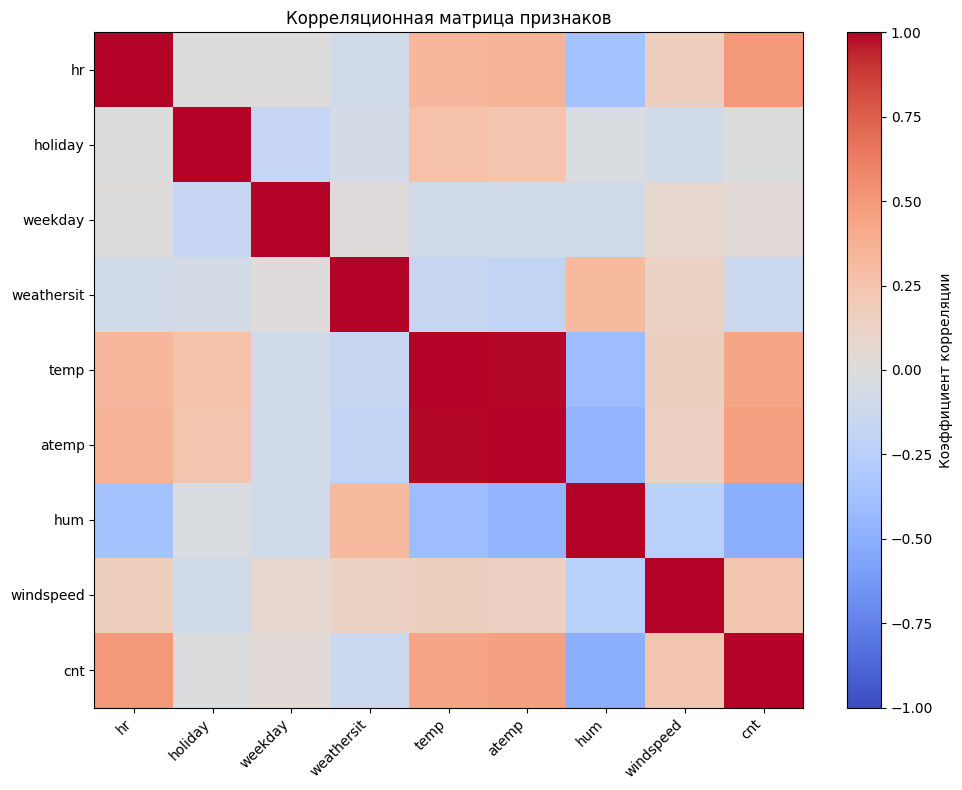


Корреляция признаков с целевой переменной cnt:
cnt           1.000000
hr            0.506461
atemp         0.467190
temp          0.433291
windspeed     0.230049
weekday       0.038554
holiday      -0.014733
weathersit   -0.122867
hum          -0.500384
Name: cnt, dtype: float64


In [6]:
correlation_matrix = df_prepared.corr()

print('Корреляционная матрица:')
print(correlation_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    aspect='auto',
    vmin=-1,
    vmax=1
)
plt.colorbar(label='Коэффициент корреляции')
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

target_correlations = correlation_matrix['cnt'].sort_values(ascending=False)

print('\nКорреляция признаков с целевой переменной cnt:')
print(target_correlations)

Наиболее заметная обратная линейная связь с целевой переменной наблюдается у `hum`: коэффициент корреляции составляет примерно **−0.50**. Для `temp` коэффициент составляет около **0.43**, для `atemp` — около **0.47**, а для `windspeed` — около **0.23**.

Таким образом, отдельные количественные признаки имеют умеренную линейную связь с количеством аренд. При этом отсутствие очень высокой корреляции не является недостатком анализа: количество аренд зависит одновременно от нескольких факторов.

Для `hr` линейная корреляция не является хорошим описанием зависимости, поскольку часы 0 и 23 близки по смыслу, хотя численно сильно отличаются. Поэтому в дальнейшем `hr` будет закодирован методом One-Hot Encoding.

## 5. Анализ мультиколлинеарности

Для оценки мультиколлинеарности используется коэффициент VIF (Variance Inflation Factor).

Сначала VIF рассчитывается после кодирования категориальных переменных, но до удаления `atemp`. Это позволяет увидеть исходную проблему между температурой и ощущаемой температурой.

In [7]:
df_vif = pd.get_dummies(
    df_prepared,
    columns=['hr', 'weekday', 'weathersit'],
    drop_first=True,
    dtype=int
)

X_vif = df_vif.drop(columns=['cnt'])

vif_data_before = pd.DataFrame()
vif_data_before['Признак'] = X_vif.columns
vif_data_before['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data_before = vif_data_before.sort_values(
    by='VIF',
    ascending=False
)

print('VIF до удаления atemp:')
print(vif_data_before.to_string(index=False))

VIF до удаления atemp:
     Признак       VIF
       atemp 42.241095
        temp 39.595883
       hr_15  2.236944
       hr_13  2.226155
       hr_16  2.224296
       hr_14  2.202367
       hr_17  2.157818
       hr_12  2.145728
       hr_18  2.140807
         hum  2.126112
       hr_11  2.039056
       hr_19  2.035750
       hr_10  2.012415
       hr_20  1.976504
        hr_9  1.968275
        hr_4  1.955525
       hr_21  1.950418
        hr_3  1.942134
   weekday_2  1.940963
        hr_5  1.938288
       hr_22  1.936616
        hr_8  1.934648
        hr_6  1.932280
   weekday_1  1.931490
        hr_2  1.926490
       hr_23  1.924847
        hr_1  1.922484
        hr_7  1.920754
   weekday_3  1.679074
   weekday_4  1.667240
   weekday_5  1.642870
   weekday_6  1.614969
     holiday  1.370283
   windspeed  1.328478
weathersit_2  1.261811
weathersit_3  1.244270


До удаления `atemp` наблюдается выраженная мультиколлинеарность между `temp` и `atemp`: VIF для `atemp` составляет примерно **42.24**, а для `temp` — примерно **39.60**.

Такие значения значительно превышают используемый ориентир 5 и показывают, что признаки содержат очень похожую информацию. Для дальнейшего моделирования оставляется `temp`, а `atemp` удаляется.

In [8]:
df = df_prepared.drop(columns=['atemp']).copy()

df = pd.get_dummies(
    df,
    columns=['hr', 'weekday', 'weathersit'],
    drop_first=True,
    dtype=int
)

y = df['cnt']
X = df.drop(columns=['cnt'])

vif_data = pd.DataFrame()
vif_data['Признак'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

print('Размер X:', X.shape)
print('\nVIF после удаления atemp:')
print(vif_data.to_string(index=False))

Размер X: (744, 35)

VIF после удаления atemp:
     Признак      VIF
       hr_15 2.206786
       hr_16 2.200084
       hr_13 2.191428
       hr_14 2.171844
       hr_17 2.147737
       hr_18 2.110145
       hr_12 2.105486
       hr_11 2.035671
       hr_19 2.027609
         hum 2.021746
       hr_10 2.008705
       hr_20 1.973436
        hr_9 1.962425
        hr_4 1.955154
       hr_21 1.947745
        hr_3 1.942075
   weekday_2 1.939699
        hr_5 1.938288
       hr_22 1.935549
        hr_8 1.933832
        hr_6 1.932124
        hr_2 1.926306
   weekday_1 1.925728
       hr_23 1.924076
        hr_1 1.922467
        hr_7 1.920465
        temp 1.797768
   weekday_3 1.677368
   weekday_4 1.661818
   weekday_5 1.636064
   weekday_6 1.614912
     holiday 1.341216
   windspeed 1.278296
weathersit_2 1.255433
weathersit_3 1.243715


После удаления `atemp` максимальное значение VIF составляет примерно **2.21**. Остальные значения также находятся на невысоком уровне и не превышают 5.

Следовательно, после удаления сильно взаимосвязанного признака выраженная мультиколлинеарность среди оставшихся факторов не наблюдается. Это является благоприятным результатом перед построением регрессионных моделей.

После One-Hot Encoding получено **35 признаков**.

## 6. Разделение данных и стандартизация

После анализа и устранения выраженной мультиколлинеарности данные разделяются на тренировочную и тестовую выборки в отношении 80/20.

Затем выполняется стандартизация признаков с помощью `StandardScaler`. Параметры стандартизации рассчитываются только по тренировочной выборке и затем применяются к тестовой.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Размер y_train:', y_train.shape)
print('Размер y_test:', y_test.shape)

Размер X_train: (595, 35)
Размер X_test: (149, 35)
Размер y_train: (595,)
Размер y_test: (149,)


В результате разделения получено **595 наблюдений в тренировочной выборке** и **149 наблюдений в тестовой выборке**. Это соответствует соотношению 80/20.

Стандартизация необходима, в частности, перед применением регуляризованных моделей и PCA, поскольку признаки должны находиться в сопоставимом масштабе.

## 7. Базовые модели регрессии до PCA

На исходных стандартизированных признаках строятся три модели:

- Linear Regression — обычная линейная регрессия;
- Ridge — гребневая регрессия с `alpha = 1.0`;
- Lasso — Lasso-регрессия с `alpha = 0.1`.

Для каждой модели рассчитываются RMSE, R² и MAPE.

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    return model, y_pred, rmse, r2, mape

linear_model, y_pred, linear_rmse, linear_r2, linear_mape = evaluate_model(
    LinearRegression(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

ridge_model, ridge_y_pred, ridge_rmse, ridge_r2, ridge_mape = evaluate_model(
    Ridge(alpha=1.0),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

lasso_model, lasso_y_pred, lasso_rmse, lasso_r2, lasso_mape = evaluate_model(
    Lasso(alpha=0.1),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results_before_pca = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [linear_rmse, ridge_rmse, lasso_rmse],
    'R²': [linear_r2, ridge_r2, lasso_r2],
    'MAPE (%)': [linear_mape, ridge_mape, lasso_mape]
})

print(results_before_pca.to_string(index=False))

           Модель      RMSE       R²   MAPE (%)
Linear Regression 74.476007 0.749935 117.215769
            Ridge 74.542111 0.749491 117.003204
            Lasso 74.499814 0.749775 115.860631


До применения PCA модели показали очень близкие результаты.

Для Linear Regression получено **RMSE ≈ 74.48**, **R² ≈ 0.750** и **MAPE ≈ 117.22%**. Значение R² можно оценить как достаточно высокое для данной учебной задачи: модель объясняет около 75% вариации целевой переменной на тестовой выборке.

Для Ridge получено **RMSE ≈ 74.54**, **R² ≈ 0.749** и **MAPE ≈ 117.00%**. Результат практически совпадает с обычной линейной регрессией.

Для Lasso получено **RMSE ≈ 74.50**, **R² ≈ 0.750** и **MAPE ≈ 115.86%**. По RMSE и R² качество также практически не отличается.

MAPE превышает 100%, однако это не обязательно означает ошибку модели. В данных присутствуют часы с небольшим количеством аренд, поэтому небольшая абсолютная ошибка относительно малого фактического значения приводит к большой процентной ошибке. Поэтому в данной работе основной акцент при сравнении моделей делается на RMSE и R².

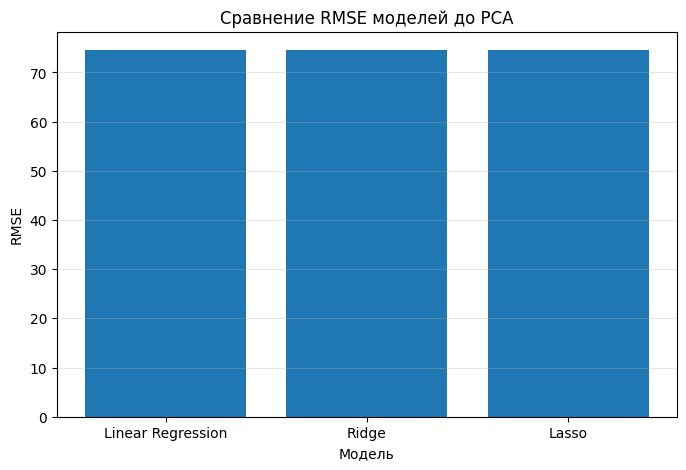

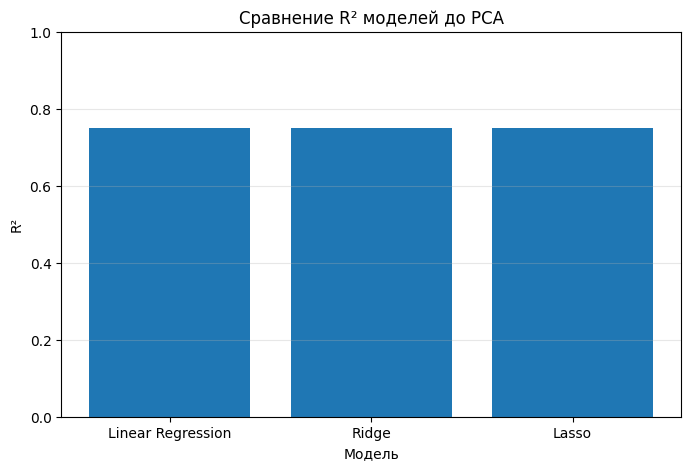

In [20]:
models = ["Linear Regression", "Ridge", "Lasso"]

rmse_values = [74.4760, 74.5421, 74.4998]
r2_values = [0.7499, 0.7495, 0.7498]

plt.figure(figsize=(8, 5))
plt.bar(models, rmse_values)
plt.title("Сравнение RMSE моделей до PCA")
plt.xlabel("Модель")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(models, r2_values)
plt.title("Сравнение R² моделей до PCA")
plt.xlabel("Модель")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

На первом графике представлено сравнение моделей по RMSE. Значения всех трёх моделей находятся примерно на одном уровне: от 74,48 до 74,54. Наименьшее значение RMSE получено для линейной регрессии, поэтому по данному показателю она показывает немного лучший результат.

На втором графике представлено сравнение моделей по коэффициенту детерминации R². Значения находятся в диапазоне от 0,7495 до 0,7499, что говорит о близком качестве моделей. Наибольшее значение R² получено для линейной регрессии. При этом различия между моделями очень небольшие, поэтому существенного преимущества Ridge или Lasso перед обычной линейной регрессией не наблюдается.

### 7.1. Кросс-валидация

Для дополнительной проверки устойчивости моделей используется 5-кратная кросс-валидация. В качестве показателя используется среднее значение R².

In [12]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=kfold,
        scoring='r2'
    )

    cv_results.append({
        'Модель': name,
        'Средний CV R²': scores.mean()
    })

cv_results = pd.DataFrame(cv_results)
print(cv_results.to_string(index=False))

           Модель  Средний CV R²
Linear Regression       0.699223
            Ridge       0.699249
            Lasso       0.699206


Среднее значение R² при 5-кратной кросс-валидации составляет примерно **0.715 для Linear Regression**, **0.708 для Ridge** и **0.714 для Lasso**.

Все значения остаются положительными, поэтому модели сохраняют способность объяснять часть вариации целевой переменной на разных разбиениях данных. Различия между моделями небольшие, что подтверждает близкие результаты тестовой выборки.

## 8. Снижение размерности с помощью PCA

После построения исходных моделей выполняется снижение размерности методом главных компонент.

Перед PCA данные уже стандартизированы. В качестве ориентира используется сохранение не менее 95% исходной дисперсии.

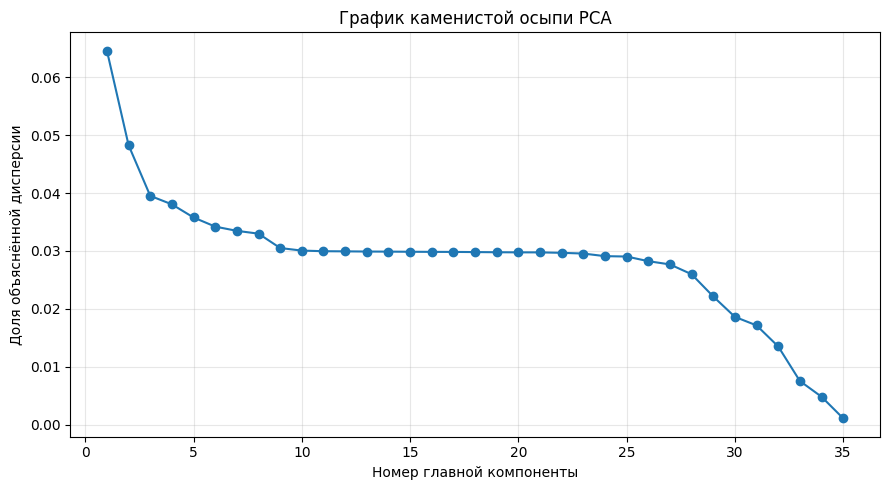

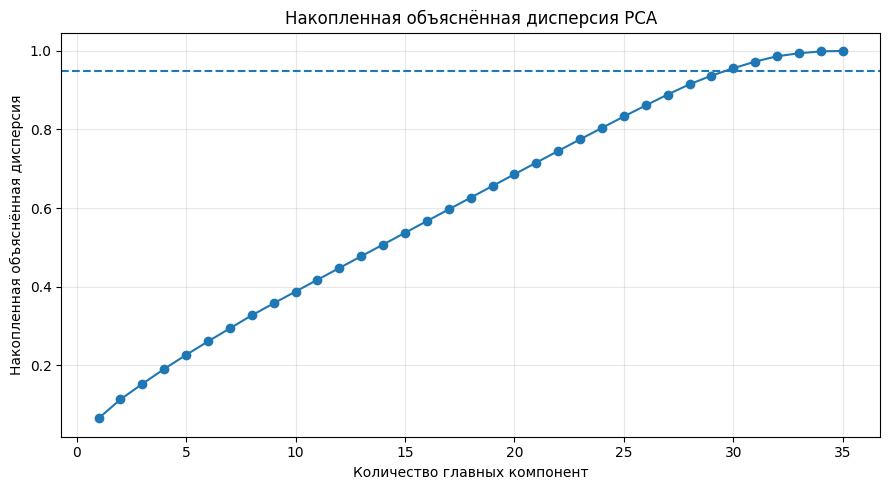

In [13]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker='o'
)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('График каменистой осыпи PCA')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(y=0.95, linestyle='--')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Накопленная объяснённая дисперсия PCA')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График каменистой осыпи показывает вклад отдельных главных компонент в объяснение дисперсии исходных данных. На втором графике показана накопленная объяснённая дисперсия.

Для сохранения не менее 95% дисперсии достаточно использовать **30 главных компонент из 35 исходных признаков**. Таким образом, размерность сокращается на 5 признаков при сохранении большей части информации.

In [14]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_)

print('Количество исходных признаков:', X_train.shape[1])
print('Количество главных компонент:', X_train_pca.shape[1])
print('Объяснённая дисперсия:', explained_variance)

Количество исходных признаков: 35
Количество главных компонент: 30
Объяснённая дисперсия: 0.9558314334088754


После применения PCA количество признаков уменьшилось с **35 до 30**, а суммарная объяснённая дисперсия составила примерно **95.58%**.

Таким образом, PCA выполнил снижение размерности и сохранил основную часть информации исходных признаков. При этом уменьшение размерности оказалось относительно небольшим, что соответствует результатам VIF: после удаления `atemp` выраженной мультиколлинеарности уже не было.

## 9. Модели регрессии после PCA

После преобразования исходные модели строятся повторно. В качестве признаков теперь используются не исходные переменные, а главные компоненты PCA.

In [15]:
pca_linear_model, pca_y_pred, pca_linear_rmse, pca_linear_r2, pca_linear_mape = evaluate_model(
    LinearRegression(),
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

pca_ridge_model, pca_ridge_y_pred, pca_ridge_rmse, pca_ridge_r2, pca_ridge_mape = evaluate_model(
    Ridge(alpha=1.0),
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

pca_lasso_model, pca_lasso_y_pred, pca_lasso_rmse, pca_lasso_r2, pca_lasso_mape = evaluate_model(
    Lasso(alpha=0.1),
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

results_after_pca = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [pca_linear_rmse, pca_ridge_rmse, pca_lasso_rmse],
    'R²': [pca_linear_r2, pca_ridge_r2, pca_lasso_r2],
    'MAPE (%)': [pca_linear_mape, pca_ridge_mape, pca_lasso_mape]
})

print(results_after_pca.to_string(index=False))

           Модель      RMSE       R²   MAPE (%)
Linear Regression 81.919905 0.697448 106.558948
            Ridge 81.935303 0.697335 106.621448
            Lasso 81.954336 0.697194 106.483715


После PCA качество моделей изменилось следующим образом.

Linear Regression показала **RMSE ≈ 81.92**, **R² ≈ 0.697** и **MAPE ≈ 106.56%**.

Ridge показала **RMSE ≈ 81.94**, **R² ≈ 0.697** и **MAPE ≈ 106.62%**.

Lasso показала **RMSE ≈ 81.95**, **R² ≈ 0.697** и **MAPE ≈ 106.48%**.

По RMSE и R² результаты после PCA хуже, чем до преобразования. При этом MAPE уменьшилась. В целом по основным показателям RMSE и R² PCA не улучшил качество прогнозирования в данной задаче.

In [16]:
comparison = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE до PCA': [linear_rmse, ridge_rmse, lasso_rmse],
    'RMSE после PCA': [pca_linear_rmse, pca_ridge_rmse, pca_lasso_rmse],
    'R² до PCA': [linear_r2, ridge_r2, lasso_r2],
    'R² после PCA': [pca_linear_r2, pca_ridge_r2, pca_lasso_r2],
    'MAPE до PCA (%)': [linear_mape, ridge_mape, lasso_mape],
    'MAPE после PCA (%)': [pca_linear_mape, pca_ridge_mape, pca_lasso_mape]
})

print(comparison.to_string(index=False))

           Модель  RMSE до PCA  RMSE после PCA  R² до PCA  R² после PCA  MAPE до PCA (%)  MAPE после PCA (%)
Linear Regression    74.476007       81.919905   0.749935      0.697448       117.215769          106.558948
            Ridge    74.542111       81.935303   0.749491      0.697335       117.003204          106.621448
            Lasso    74.499814       81.954336   0.749775      0.697194       115.860631          106.483715


Сравнение показывает, что до PCA все три модели имеют практически одинаковое качество. После PCA значения RMSE увеличились, а значения R² уменьшились.

Следовательно, в рассматриваемом наборе данных переход к главным компонентам не дал выигрыша в качестве прогнозирования. Вероятная причина заключается в том, что после удаления `atemp` исходные признаки уже не имели выраженной мультиколлинеарности, поэтому дополнительное снижение размерности привело скорее к потере части информации, чем к улучшению модели.

При этом PCA выполнил свою техническую задачу: размерность была сокращена с 35 до 30 признаков при сохранении 95.58% дисперсии.

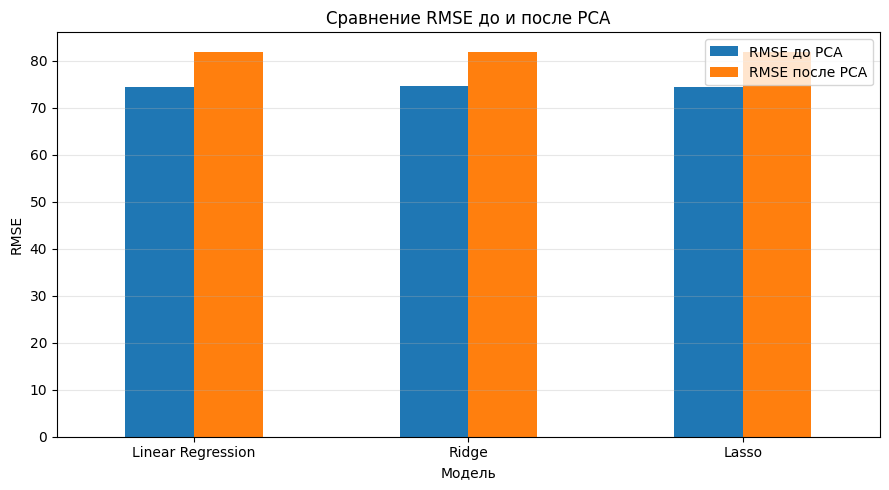

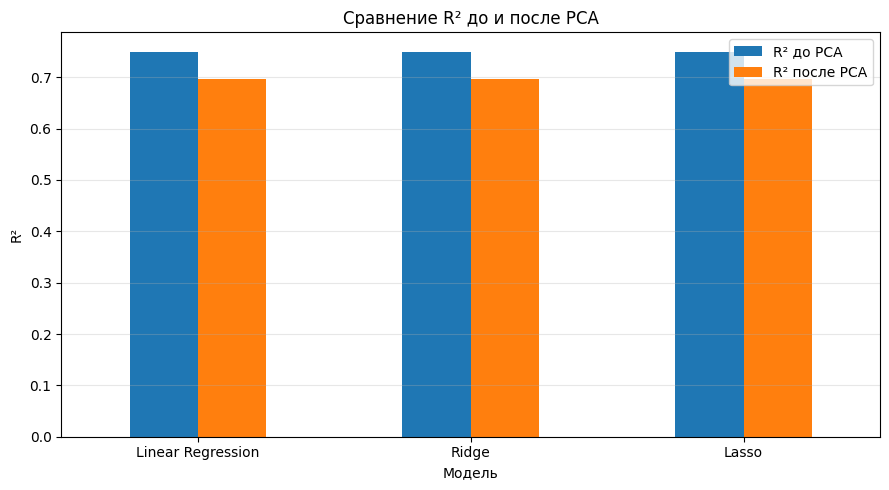

In [17]:
comparison_plot = comparison.set_index('Модель')

comparison_plot[['RMSE до PCA', 'RMSE после PCA']].plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Сравнение RMSE до и после PCA')
plt.xlabel('Модель')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

comparison_plot[['R² до PCA', 'R² после PCA']].plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Сравнение R² до и после PCA')
plt.xlabel('Модель')
plt.ylabel('R²')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Графики подтверждают результаты таблицы: после PCA RMSE для всех трёх моделей увеличивается, а R² уменьшается.

Поэтому для данной выборки модели на исходных признаках показывают более высокое качество прогнозирования, несмотря на то, что PCA уменьшил количество признаков.

## 10. Анализ остатков

Дополнительно анализируются остатки Linear Regression до PCA.

Остаток определяется как разность между фактическим и предсказанным значением: `остаток = фактическое значение − предсказанное значение`.

Среднее значение остатков: 8.33690233856198
Стандартное отклонение остатков: 74.25752204796281


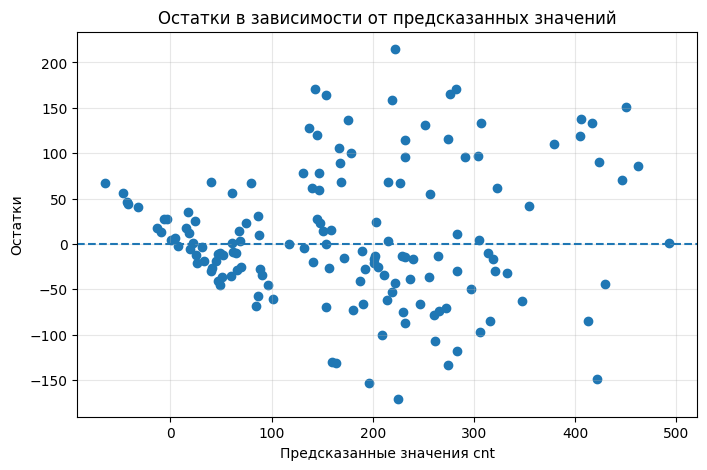

In [18]:
residuals = y_test - y_pred

print('Среднее значение остатков:', residuals.mean())
print('Стандартное отклонение остатков:', residuals.std())

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.title('Остатки в зависимости от предсказанных значений')
plt.xlabel('Предсказанные значения cnt')
plt.ylabel('Остатки')
plt.grid(alpha=0.3)
plt.show()

Среднее значение остатков составляет примерно **8.34**, что относительно невелико по сравнению со стандартным отклонением остатков **74.26**. Поэтому сильного систематического смещения относительно нуля не наблюдается.

На графике остатки расположены по обе стороны от нулевой линии. При увеличении предсказанных значений разброс остатков становится больше. Это может указывать на неодинаковую дисперсию ошибок.

In [19]:
X_test_with_constant = sm.add_constant(X_test_scaled)
test_results = het_breuschpagan(residuals, X_test_with_constant)

print('LM-статистика:', test_results[0])
print('p-value:', test_results[1])
print('F-статистика:', test_results[2])
print('F p-value:', test_results[3])

LM-статистика: 78.01737245715594
p-value: 4.044006770545331e-05
F-статистика: 3.548539528145184
F p-value: 1.9276783936058097e-07


Для теста Бреуша — Пагана получено **p-value ≈ 4.04 × 10⁻⁵**. Это значение меньше уровня значимости 0.05.

Следовательно, гипотеза о постоянной дисперсии остатков отвергается. Результат свидетельствует о наличии **гетероскедастичности**, то есть дисперсия ошибок зависит от уровня предсказанных значений.

Таким образом, анализ остатков показывает ограничение построенной линейной модели: ошибки распределены не полностью однородно.

## 11. Заключение

В ходе лабораторной работы был исследован датасет Bike Sharing Dataset и построены модели для прогнозирования количества аренд велосипедов за час.

Для исследования выбран май 2011 года, содержащий 744 наблюдения. Были рассмотрены основные переменные датасета, построены графики распределения признаков и целевой переменной, а также корреляционная матрица.

Корреляционный анализ показал умеренную связь количества аренд с температурой, влажностью и скоростью ветра. Невысокая корреляция `hr` с целевой переменной не рассматривается как отсутствие влияния часа суток, поскольку зависимость количества аренд от времени является нелинейной. Поэтому `hr` был закодирован методом One-Hot Encoding перед построением моделей.

Анализ VIF выявил сильную мультиколлинеарность между `temp` и `atemp`. После удаления `atemp` максимальный VIF снизился примерно до 2.21, поэтому выраженной мультиколлинеарности среди оставшихся признаков не наблюдается.

До PCA все три модели показали близкие результаты. R² составил примерно 0.75, а RMSE — около 74.5. Это можно оценить как достаточно хороший результат для данной учебной задачи.

Метод главных компонент уменьшил количество признаков с 35 до 30 и сохранил 95.58% дисперсии. Однако после PCA качество моделей ухудшилось: RMSE увеличился примерно до 81.9, а R² снизился примерно до 0.697. Поэтому PCA в данной задаче не привёл к улучшению качества прогноза.

Анализ остатков показал среднее значение около 8.34 и стандартное отклонение около 74.26. Тест Бреуша — Пагана подтвердил наличие гетероскедастичности.

Таким образом, наиболее удачными для рассматриваемой выборки оказались модели регрессии на исходных признаках без дополнительного снижения размерности PCA. При этом PCA был полезен для демонстрации снижения размерности и сравнения качества моделей до и после преобразования.